# Sideways into a gap

Step 12.1. The parking of Phase 11 (`parking.ipynb`) ends nose first against a box: its body sweeps 40-50
cm behind where it stops, so between two boxes it needs a gap of ~0.7 m. The goal here: a tight gap, the
car sliding into it sideways, with a drift on the way. Designed in the refitted model (`identification.ipynb`,
`vehicle_model.forces_fit`), then open loop on the car, then closed loop (`gap_node`).

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import vehicle_model as vm

plt.rcParams['figure.dpi'] = 72
B = '../data/bags'
H = 0.002
FRONT, REAR, HALF = 0.2165, -0.0435, 0.10     # car outline from the rear axle
OUTLINE = np.array([[x, y] for x in np.linspace(REAR, FRONT, 14) for y in (-HALF, HALF)] +
                   [[x, y] for x in (REAR, FRONT) for y in np.linspace(-HALF, HALF, 6)])


def read(run, name):
    return pd.read_parquet(f'{B}/{run}_parquet/{name}.parquet')

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## The slot

Two boxes 0.35 m long and 0.30 m deep, their sides flush with the car where it stopped, one ahead of its nose
and one behind its tail, open on the side the car came from. The slot is the shortest distance between them
that the body of the car never crossed, from 3 m before the run (the car came along the line of the start)
to the stop. The car is 0.26 m long.

In [2]:
def slot(h, depth=0.30, box=0.35):
    # h: (steps, 3, n) rear axle x, y and heading of n runs. The shortest slot, best open side
    xf, yf, pf = h[-1, 0], h[-1, 1], h[-1, 2]
    n = h.shape[2]
    lane = np.broadcast_to(np.array([[-x, 0.0, 0.0] for x in np.arange(0.05, 3.0, 0.05)])[:, :, None], (59, 3, n))
    bins, w = np.arange(0.0, 4.0, 0.01), int(round(box / 0.01))
    best = np.full(n, np.inf)
    for lo, hi in ((-HALF, -HALF + depth), (HALF - depth, HALF)):
        occ = {'nose': np.zeros((n, len(bins)), bool), 'tail': np.zeros((n, len(bins)), bool)}
        for x, y, p in np.concatenate([lane, h]):
            c, s = np.cos(p - pf), np.sin(p - pf)
            ox = (x - xf) * np.cos(pf) + (y - yf) * np.sin(pf)
            oy = -(x - xf) * np.sin(pf) + (y - yf) * np.cos(pf)
            px = ox[:, None] + c[:, None] * OUTLINE[:, 0] - s[:, None] * OUTLINE[:, 1]
            py = oy[:, None] + s[:, None] * OUTLINE[:, 0] + c[:, None] * OUTLINE[:, 1]
            inside = (py > lo + 1e-3) & (py < hi - 1e-3)
            for key, dist in (('nose', px - FRONT), ('tail', REAR - px)):
                k = np.floor(dist / 0.01).astype(int)
                ok = inside & (k >= 0) & (k < len(bins))
                occ[key][np.repeat(np.arange(n)[:, None], k.shape[1], axis=1)[ok], k[ok]] = True
        room = []
        for key in ('nose', 'tail'):
            c = np.concatenate([np.zeros((n, 1), int), np.cumsum(occ[key], axis=1)], axis=1)
            free = (c[:, w:] - c[:, :-w]) == 0
            room.append(np.where(free.any(axis=1), free.argmax(axis=1), len(bins)) * 0.01)
        best = np.minimum(best, FRONT - REAR + room[0] + room[1])
    return best


def car_path(run, lag=0.065):
    # rear axle from the lidar path and heading from the gyro path, on the car's time (lidar lag)
    o, g = read(run, 'lidar_path'), read(run, 'gyro_path')
    t = np.arange(o['t'].iloc[0], o['t'].iloc[-1], 0.01)
    return np.stack([np.interp(t, o['t'], o['x']), np.interp(t, o['t'], o['y']), np.interp(t, g['t'], g['psi'])], axis=1)


grip = ['hbl_1', 'hbl_2', 'hbl_3', 'hbl_4', 'hbl_8', 'hbf_3', 'hbf_4', 'hbf_5']
pd.Series({run: slot(car_path(run)[:, :, None])[0] for run in grip}, name='slot [m]').round(3).to_frame().T

,hbl_1,hbl_2,hbl_3,hbl_4,hbl_8,hbf_3,hbf_4,hbf_5
slot [m],0.72,0.73,0.73,0.71,0.73,0.73,0.74,0.81


## In the model

The car from its commands: the steering through the dead time, the servo's rate limit and lag, the rear
wheel speed from the speed command (`vehicle_model.wheel_accel`), the refitted tires. A run: a straight at
v0, one segment of steering and speed, then braked with a steering held to the stop.

In [3]:
def run(segs, v0, t_max=4.0):
    # segs: (n, k, 3) duration, steering command, speed command; the last lasts to the stop. Heading 0, rear
    # axle at the origin at t = 0. Returns (steps, 3, n) rear axle x, y, heading every 10 ms
    n, k = segs.shape[:2]
    ends = np.cumsum(segs[:, :, 0], axis=1)
    X, Y, psi = np.full(n, vm.LR), np.zeros(n), np.zeros(n)
    vx, vy, r = 0.97 * v0, np.zeros(n), np.zeros(n)
    u = v0.copy()
    servo = d = np.full(n, np.interp(0.0, vm.CMD, vm.DEL))
    ax = ay = np.zeros(n)
    go = np.ones(n, bool)
    out = []
    for i in range(int(t_max / H)):
        t = i * H - vm.STEER_DEAD
        j = np.minimum((ends < t).sum(axis=1), k - 1)
        steer = np.where(t < 0, 0.0, segs[np.arange(n), j, 1])
        speed = np.where(t < 0, v0, segs[np.arange(n), j, 2])
        braked = speed < 0.02
        servo = servo + np.clip(np.interp(steer, vm.CMD, vm.DEL) - servo, -vm.STEER_RATE * H, vm.STEER_RATE * H)
        d = d + H * (servo - d) / vm.FIT['tau']
        u = np.maximum(u + H * vm.wheel_accel(u, speed), 0.0)
        fx, fy, mz = vm.forces_fit(vx, vy, r, d, u, braked, ax, ay)
        ax, ay = fx / vm.M, fy / vm.M
        c, s = np.cos(psi), np.sin(psi)
        X, Y, psi = X + go * H * (vx * c - vy * s), Y + go * H * (vx * s + vy * c), psi + go * H * r
        vx, vy, r = np.maximum(vx + go * H * (ax + vy * r), 0.0), vy + go * H * (ay - vx * r), r + go * H * mz / vm.IZ
        go &= ~(braked & (np.hypot(vx, vy + vm.LF * r) < 0.04) & (np.hypot(vx, vy - vm.LR * r) < 0.04))
        vx, vy, r = vx * go, vy * go, r * go
        if i % 5 == 0:
            out.append((X - vm.LR * np.cos(psi), Y - vm.LR * np.sin(psi), psi))
        if not go.any():
            break
    return np.array(out), ~go


def plan(p):
    # p: (n, 7) v0, segment duration, steering, speed, braked duration with steering s2, then steering s3
    n = len(p)
    segs = np.stack([np.c_[p[:, 1], p[:, 2], p[:, 3]], np.c_[p[:, 4], p[:, 5], np.zeros(n)],
                     np.c_[np.full(n, 9.0), p[:, 6], np.zeros(n)]], axis=1)
    return run(segs, p[:, 0])

Random runs, 6000: straight at 0.4-1.13 m/s, a segment of 0-2 s with any steering at 0.6, 1.0 or 1.5 m/s
(full throttle), braked with one steering for 0-1.2 s, then another. The tightest slot for each final
heading:

In [4]:
rng = np.random.default_rng(0)
LO = np.array([0.4, 0.0, -0.52, 0.3, 0.0, -0.52, -0.52])
HI = np.array([1.13, 2.0, 0.52, 1.5, 1.2, 0.52, 0.52])
P = LO + (HI - LO) * rng.uniform(size=(6000, 7))
P[:, 3] = rng.choice([0.6, 1.0, 1.5], len(P))
G, heading = np.full(len(P), np.inf), np.zeros(len(P))
for a in range(0, len(P), 1000):
    h, stopped = plan(P[a:a + 1000])
    G[a:a + 1000] = np.where(stopped, slot(h), np.inf)
    heading[a:a + 1000] = np.degrees(h[-1, 2])
bins = np.arange(30, 211, 30)
env = pd.Series({f'{lo}-{lo + 30}': G[(heading >= lo) & (heading < lo + 30)].min() for lo in bins[:-1]}, name='tightest slot [m]')
env.round(3).to_frame().T

,30-60,60-90,90-120,120-150,150-180,180-210
tightest slot [m],0.55,0.53,0.55,0.51,0.48,0.56


The best of each band refined (Nelder-Mead, the final heading held within 5 deg of the band's middle):

In [5]:
def refine(p0, target):
    def cost(x):
        h, st = plan(np.clip(x, LO, HI)[None])
        return slot(h)[0] + 2.0 * max(abs(np.degrees(h[-1, 2, 0]) - target) - 5, 0) / 57.3 if st[0] else 9.0
    r = minimize(cost, p0, method='Nelder-Mead', options={'maxfev': 200, 'xatol': 1e-3, 'fatol': 1e-4})
    return np.clip(r.x, LO, HI), r.fun


rows = []
for lo in (60, 90, 150, 180):
    band = np.where((heading >= lo - 15) & (heading < lo + 15))[0]
    x, g = refine(P[band[np.argmin(G[band])]], lo)
    h, _ = plan(x[None])
    rows.append({'heading [deg]': np.degrees(h[-1, 2, 0]), 'slot [m]': slot(h)[0], 'v0': x[0], 'segment [s]': x[1],
                 'steering': x[2], 'speed': x[3], 'braked [s]': x[4], 'braked steering': x[5], 'then': x[6]})
best = pd.DataFrame(rows)
best.round(2)

,heading [deg],slot [m],v0,segment [s],steering,speed,braked [s],braked steering,then
0,64.61,0.53,0.53,0.30,0.42,1.50,0.24,0.51,0.47
1,91.42,0.53,0.49,0.45,0.44,1.44,0.82,0.45,0.22
2,148.55,0.52,0.53,0.83,0.45,1.50,0.56,0.14,-0.23
3,178.46,0.47,0.43,0.93,0.52,1.50,0.73,-0.06,0.31


### Result

Under 150 deg the tightest slot is 0.51-0.55 m, from 150 to 180 deg 0.48: the tightest runs turn round. The
tightest refined, 0.47 m at 178 deg: from 0.43 m/s, 0.93 s at full lock and full throttle, then braked. No run
here gets under 0.47 m (1.8 car lengths); the grip parking needs 0.71-0.81 (above).

### The kick

Straight at 0.4 m/s, then full lock and full throttle (the speed loop saturates, the wheels spin up at
7 m/s2 and the tail steps out), braked when the heading reaches brake_at, the slide at one steering:

In [6]:
rows, paths = [], {}
for brake_at in (110, 120, 130, 140, 150):
    for steer in (0.52, 0.25, 0.0, -0.15):
        # the kick until brake_at: its time from a kick run without brake
        segs = np.array([[[0.0, 0.52, 1.5], [9.0, 0.52, 1.5]]])
        h, _ = run(segs, np.array([0.4]), t_max=2.0)
        t_b = np.argmax(np.degrees(h[:, 2, 0]) >= brake_at) * 0.01
        h, _ = run(np.array([[[t_b, 0.52, 1.5], [9.0, steer, 0.0]]]), np.array([0.4]))
        paths[(brake_at, steer)] = h
        rows.append({'brake at [deg]': brake_at, 'slide steering': steer, 'stop [deg]': np.degrees(h[-1, 2, 0]),
                     'x [m]': h[-1, 0, 0], 'y [m]': h[-1, 1, 0], 'slot [m]': slot(h)[0]})
kick = pd.DataFrame(rows)
kick.pivot(index='brake at [deg]', columns='slide steering', values=['stop [deg]', 'slot [m]']).round(2)

stop [deg]                         slot [m]                  
slide steering      -0.15    0.00    0.25    0.52    -0.15  0.00  0.25  0.52
brake at [deg]                                                              
110                144.71  147.90  154.88  157.25     0.51  0.50  0.47  0.45
120                155.59  158.61  165.24  167.49     0.50  0.49  0.46  0.45
130                166.61  169.47  175.78  178.11     0.49  0.48  0.45  0.44
140                175.57  178.28  184.39  186.76     0.48  0.47  0.45  0.43
150                186.92  189.46  195.26  197.87     0.47  0.46  0.44  0.43

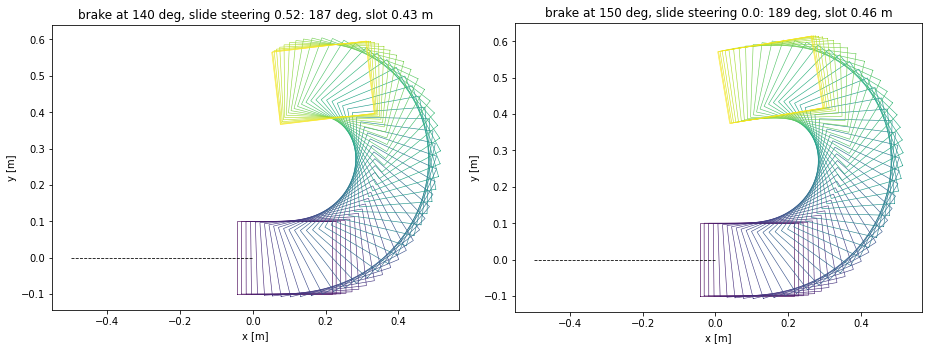

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
car = np.array([[REAR, -HALF], [FRONT, -HALF], [FRONT, HALF], [REAR, HALF], [REAR, -HALF]])
for k, key in enumerate([(140, 0.52), (150, 0.0)]):
    h = paths[key]
    for i in range(0, len(h), 3):
        x, y, p = h[i, :, 0]
        R = np.array([[np.cos(p), np.sin(p)], [-np.sin(p), np.cos(p)]])
        pts = car @ R + [x, y]
        ax[k].plot(pts[:, 0], pts[:, 1], color=plt.cm.viridis(i / len(h)), lw=0.6)
    ax[k].plot([-0.5, 0.0], [0, 0], 'k--', lw=0.8)
    ax[k].set(title=f'brake at {key[0]} deg, slide steering {key[1]}: {np.degrees(h[-1, 2, 0]):.0f} deg, slot {slot(h)[0]:.2f} m',
              xlabel='x [m]', ylabel='y [m]')
    ax[k].set_aspect('equal')
plt.tight_layout()
plt.show()

### Result

Braked at 110-150 deg the model stops at 145-198 deg: 10-11 deg further per 10 deg of brake, 12 deg from the
slide steering (-0.15 .. full lock). The slot 0.43-0.51 m, tighter the later it brakes and the more it steers.

## On the car, open loop

`scripts/handbrake.py 0.4 0.5 <brake_at> 0.52 <steering braked> 1.5`: 1 s ramp to 0.4 m/s, 0.5 s straight,
kick, brake when the script's gyro heading reaches brake_at. `hbk_1-6` without boxes (`hbk_1`, `hbk_2`,
`hbk_5`, `hbk_6`: 120, full lock; `hbk_3`, `hbk_4`: 140, straight). The model's prediction, written down
before the runs, with the script's brake on a gyro 60 ms late (its tick) and 0.54% low:

In [8]:
def script(brake_at, steer_braked, lag=0.06):
    # handbrake.py from the end of its ramp (0.19 m on): the kick after 0.5 s, the brake when the gyro heading
    # of lag ago reaches brake_at
    segs = np.array([[[0.5, 0.0, 0.4], [9.0, 0.52, 1.5]]])
    h, _ = run(segs, np.array([0.4]), t_max=3.0)
    k = np.argmax(np.degrees(h[:, 2, 0]) / 1.0054 >= brake_at) * 0.01 + lag + 0.02    # the script's 20 ms loop
    h, _ = run(np.array([[[0.5, 0.0, 0.4], [k - 0.5, 0.52, 1.5], [9.0, steer_braked, 0.0]]]), np.array([0.4]))
    return h[-1, 0, 0] + 0.19, h[-1, 1, 0], np.degrees(h[-1, 2, 0]), slot(h)[0]


RUNS = {'hbk_1': (120, 0.52), 'hbk_2': (120, 0.52), 'hbk_5': (120, 0.52), 'hbk_6': (120, 0.52), 'hbk_3': (140, 0.0),
        'hbk_4': (140, 0.0), 'hbk_7': (120, 0.52), 'hbk_8': (120, 0.52)}
rows = []
for run_, (ba, sb) in RUNS.items():
    o, g = read(run_, 'lidar_path'), read(run_, 'gyro_path')
    d = read(run_, 'drive')
    t_kick = d.loc[d['cmd_speed'] > 1.0, 't'].iloc[0]
    t_brake = d.loc[(d['t'] > t_kick) & (d['cmd_speed'] < 0.02), 't'].iloc[0]
    lag = 0.055                      # lidar lag of this session (identification.ipynb)
    ti, xy = o['t'].to_numpy() - lag, o[['x', 'y']].to_numpy()
    kick_part = (ti > t_kick) & (ti < t_brake)
    v = (xy[2:] - xy[:-2]) / (ti[2:] - ti[:-2])[:, None]
    hh = np.interp(ti[1:-1], g['t'] - lag, g['psi'])
    slip = np.degrees(np.angle(np.exp(1j * (np.arctan2(v[:, 1], v[:, 0]) - hh))))
    px, py, pp, pg = script(ba, sb)
    rows.append({'run': run_, 'brake_at': ba, 'steering braked': sb,
                 'braked at, true [deg]': np.degrees(np.interp(t_brake + vm.STEER_DEAD, g['t'] - lag, g['psi'])),
                 'r max': g.loc[(g['t'] - lag > t_kick) & (g['t'] - lag < t_brake), 'r'].max(),
                 'rear slip min [deg]': slip[kick_part[1:-1]].min(), 'stop x': xy[-1, 0], 'stop y': xy[-1, 1],
                 'stop [deg]': np.degrees(g['psi'].iloc[-1]), 'slot [m]': slot(car_path(run_)[:, :, None])[0],
                 'model x': px, 'model y': py, 'model [deg]': pp, 'model slot': pg})
open_loop = pd.DataFrame(rows).set_index('run')
open_loop.round(3)

,brake_at,steering braked,"braked at, true [deg]",r max,rear slip min [deg],stop x,stop y,stop [deg],slot [m],model x,model y,model [deg],model slot
run,,,,,,,,,,,,,
hbk_1,120,0.52,137.284,3.431,-31.810,0.696,0.476,175.752,0.43,0.672,0.492,184.541,0.44
hbk_2,120,0.52,141.864,3.672,-37.850,0.696,0.449,178.621,0.42,0.672,0.492,184.541,0.44
hbk_5,120,0.52,135.465,3.413,-34.330,0.708,0.417,168.161,0.42,0.672,0.492,184.541,0.44
hbk_6,120,0.52,139.171,3.657,-36.391,0.715,0.437,176.260,0.41,0.672,0.492,184.541,0.44
hbk_3,140,0.00,159.809,3.821,-37.872,0.639,0.480,186.345,0.44,0.601,0.518,198.466,0.45
hbk_4,140,0.00,154.893,3.811,-37.026,0.699,0.463,177.617,0.45,0.601,0.518,198.466,0.45
hbk_7,120,0.52,136.693,3.959,-35.713,0.756,0.380,169.845,0.39,0.672,0.492,184.541,0.44
hbk_8,120,0.52,139.927,3.756,-38.842,0.725,0.432,175.032,0.42,0.672,0.492,184.541,0.44


The model's wheels from the commands reach `wheel_u` = 1.163 m/s (fitted on all runs); in the drift the car's
reach 1.11-1.14 under load. The prediction with 1.13:

In [9]:
u_free = vm.p['wheel_u']
vm.p['wheel_u'] = 1.13
print('wheels up to 1.13 m/s: 120 / full lock %.1f deg, 140 / straight %.1f deg' % (script(120, 0.52)[2], script(140, 0.0)[2]))
vm.p['wheel_u'] = u_free

wheels up to 1.13 m/s: 120 / full lock 178.6 deg, 140 / straight 190.8 deg


### Result

The car kicked at 0.38 m, peaked at 3.4-4.0 rad/s with the rear axle sliding at -32..-39 deg, and braked 13-15
deg past what the script's gyro said (135-142 deg true for 120). At 120 / full lock it stopped 0.70-0.76 m
ahead, 0.38-0.48 left, 168-179 deg (six runs); at 140 / straight 178-186 deg. The slot 0.39-0.45 m, 1.5-1.7
car lengths (grip parking 0.71-0.81).

The prediction written before the runs, with the fit of that day, was 0.68 ahead, 0.56 left, 176 deg: 2 cm and
8-11 cm off. The final refit from the commands turns the car further, 185 and 198 deg; with its wheels at the
drift's 1.13 m/s 179 and 191 deg (below). The closed loop does not predict from the commands: it carries the
model with the measured wheel speed and the gyro.

### Into a gap

`hbk_7`, `hbk_8`: the same kick, two boxes placed from the four runs at 120 / full lock (their bodies, the
tightest gap that clears all four is 0.44 m, opened to 0.60): the small one (0.32 x 0.36) ending 0.383 m
ahead of the rear axle at the start, the large one (0.475 x 0.30) from 0.988 m, their sides 0.33-0.35 m left
(the lidar from the start). The car body against them, and the gaps from the stopped car's own scans:

In [10]:
SMALL, BIG = (0.054, 0.383, 0.346, 0.706), (0.988, 1.459, 0.328, 0.628)


def clearance(run_):
    h = car_path(run_)
    pts = [np.c_[x + np.cos(p) * OUTLINE[:, 0] - np.sin(p) * OUTLINE[:, 1], y + np.sin(p) * OUTLINE[:, 0] + np.cos(p) * OUTLINE[:, 1]]
           for x, y, p in h]
    def dist(q, b):
        dx = np.maximum(np.maximum(b[0] - q[:, 0], q[:, 0] - b[1]), 0)
        dy = np.maximum(np.maximum(b[2] - q[:, 1], q[:, 1] - b[3]), 0)
        return np.where((q[:, 0] > b[0]) & (q[:, 0] < b[1]) & (q[:, 1] > b[2]) & (q[:, 1] < b[3]), -1.0, np.hypot(dx, dy))
    sc = read(run_, 'scan').iloc[-8:]
    q = []
    for _, m in sc.iterrows():
        r = np.array(m['ranges'], float)
        a = m['angle_min'] + np.arange(len(r)) * m['angle_increment']
        ok = np.isfinite(r) & (r > 0.1)
        q.append(np.c_[r[ok] * np.cos(a[ok]) + 0.09225, r[ok] * np.sin(a[ok])])
    q = np.vstack(q)
    front = q[(np.abs(q[:, 1]) < HALF) & (q[:, 0] > FRONT)]
    back = q[(np.abs(q[:, 1]) < HALF) & (q[:, 0] < REAR)]
    return {'run': run_, 'stop [deg]': np.degrees(h[-1, 2]), 'closest small [cm]': 100 * min(dist(p, SMALL).min() for p in pts),
            'closest large [cm]': 100 * min(dist(p, BIG).min() for p in pts),
            'nose room [cm]': 100 * (np.percentile(front[:, 0], 5) - FRONT), 'tail room [cm]': 100 * (REAR - np.percentile(back[:, 0], 95)),
            'car side [m]': pts[-1][:, 1].min()}


pd.DataFrame([clearance(r) for r in ['hbk_7', 'hbk_8']]).set_index('run').round(3)

,stop [deg],closest small [cm],closest large [cm],nose room [cm],tail room [cm],car side [m]
run,,,,,,
hbk_7,169.854,14.371,8.386,15.314,18.084,0.274
hbk_8,175.031,11.754,7.848,12.358,22.057,0.329


### Result

Both parked, no contact: nose 15.3 / 12.4 cm from the small box, tail 18.1 / 22.1 cm from the large one; the
closest the body came 14.4 / 11.8 cm and 8.4 / 7.8 cm. `hbk_7` stopped 4-6 cm further on than the others (its
drift the strongest, 3.96 rad/s) and 10 deg short of 180.

## Closed loop

`gap_node` (`ackermann_nmpc`, `gap.launch.py`). At rest the lidar gives the gap: the side of the boxes (the
nearest line of points on the left), the two rows along it and the free stretch between them. The car holds
the line of the start at 0.4 m/s and kicks where it will stop with as much room at its nose as beyond its
swept tail (`kick_ahead`, `kick_left` where the car stopped against the kick, `sweep` how far the tail swings
past its stop). In the kick the model (`forces_fit`) is carried with what was sent and the wheel speed; the
gyro reading is `gyro_lag` older than its message, so its yaw rate corrects the model's of that time and the
heading now is the gyro's plus what the model turned since. It brakes when the model run to the stop with the
slide steering `slide_ref` ends at target; in the slide, every 20 ms, bisection on the steering (full lock ..
-0.15) to stop at target.

Gazebo (the sim car on the refit, commands 30 ms late, gyro 47 ms late; boxes as on the car, 7.5 cm further
out where the sim car stops; `kick_ahead` 0.158, `kick_left` 0.535, `sweep` 0.23 from its first run), the
floor friction changed:

In [11]:
X0, Y0, P0 = 3.010, 0.350, -0.801        # the car at the start in the sim


def sim_eval(run_, dy=0.075):
    g = read(run_, 'ground_truth')
    c, s = np.cos(-P0), np.sin(-P0)
    x = (g['x'] - X0) * c - (g['y'] - Y0) * s
    y = (g['x'] - X0) * s + (g['y'] - Y0) * c
    p = np.unwrap(g['yaw'].to_numpy()) - P0
    pts = [np.c_[xi + np.cos(pi) * OUTLINE[:, 0] - np.sin(pi) * OUTLINE[:, 1], yi + np.sin(pi) * OUTLINE[:, 0] + np.cos(pi) * OUTLINE[:, 1]]
           for xi, yi, pi in zip(x, y, p)]
    def dist(q, b):
        dx = np.maximum(np.maximum(b[0] - q[:, 0], q[:, 0] - b[1]), 0)
        dy_ = np.maximum(np.maximum(b[2] + dy - q[:, 1], q[:, 1] - b[3] - dy), 0)
        return np.hypot(dx, dy_)
    return {'run': run_, 'stop x [m]': x.iloc[-1], 'stop [deg]': np.degrees(p[-1]),
            'closest small [cm]': 100 * min(dist(q, SMALL).min() for q in pts), 'closest large [cm]': 100 * min(dist(q, BIG).min() for q in pts)}


sim = pd.DataFrame([sim_eval(r) for r in ['sim_gap16', 'sim_gap17', 'sim_gap18']]).set_index('run')
sim.insert(0, 'floor friction', [1.0, 0.93, 1.07])
sim.round(3)

,floor friction,stop x [m],stop [deg],closest small [cm],closest large [cm]
run,,,,,
sim_gap16,1.00,0.697,180.604,9.690,6.522
sim_gap17,0.93,0.716,182.166,11.280,6.516
sim_gap18,1.07,0.660,180.334,5.994,7.243


On the car, the boxes of `hbk_7`. `gap_1-3` ran the model before the locked rear across the wheel, with the
gyro's yaw rate taken half-way each step (`gap_1`: `kick_ahead` 0.21 from the model, `kick_left` 0.46; `gap_2`:
`kick_ahead` 0.25, the brake decided with the slide at full lock, `slide_ref` 0.52; `gap_3`: the same aimed at
176.5 deg). `gap_4` (next morning, the boxes put back on their marks): the locked rear 0.91 across the wheel,
the gyro's error taken in full, `kick_ahead` 0.245, `slide_ref` 0.2:

In [12]:
rows = []
for run_ in ['gap_1', 'gap_2', 'gap_3', 'gap_4']:
    s = read(run_, 'gap_state')
    k = s.index[s['phase'] == 4][0]
    slide = s[s['phase'] == 4]
    row = clearance(run_)
    row.update({'braked at, node [deg]': np.degrees(s.loc[k, 'heading_now']),
                'slide steering': ' '.join(f'{v:+.2f}' for v in slide['steer'].iloc[:12:2]),
                'tick max [ms]': s['tick_ms'].max()})
    rows.append(row)
closed = pd.DataFrame(rows).set_index('run')
closed.round(3)

,stop [deg],closest small [cm],closest large [cm],nose room [cm],tail room [cm],car side [m],"braked at, node [deg]",slide steering,tick max [ms]
run,,,,,,,,,
gap_1,183.752,11.521,4.117,11.876,22.233,0.343,149.873,+0.01 -0.15 -0.15 -0.15 -0.15 -0.15,2.043
gap_2,183.377,7.158,9.199,6.453,27.166,0.357,144.531,+0.25 +0.09 -0.11 -0.15 -0.15 -0.10,2.365
gap_3,172.907,14.425,7.461,15.103,18.808,0.300,133.614,+0.37 +0.52 +0.52 +0.52 +0.52 +0.39,1.963
gap_4,173.641,12.506,7.708,13.146,20.913,0.294,138.667,+0.18 +0.13 +0.04 +0.14 +0.50 +0.52,1.899


### Result

Gazebo: 180.3-182.2 deg, the stop 0.66-0.72 m along the gap with the friction +-7%, at least 6 cm from both
boxes (the parameters of that day).

On the car all four parked, no contact, the closest 4.1-14.4 cm; but 183.8, 183.4, 172.9 and 173.6 deg. The
slide steering reached its limit after one to four steps: -0.15 in `gap_1` and `gap_2` (the car kept turning),
full lock in `gap_3` and `gap_4`. For `gap_1-3` the model turned the slide after a drift brake 3.5 deg short
(its locked rear slid sideways with the friction it has straight). In `gap_4`, that fixed, the node's heading and
yaw rate matched the lidar within 0.2 deg and 0.1-0.2 rad/s through the drift, but where the controller moved
the steering off full lock in the slide (`gap_3`, `gap_4`) the car turned 5 deg less than the model
(identification.ipynb); held at full lock the model is right within 2.6 deg. Next: the brake decided with the
slide at full lock (`slide_ref` 0.52), the steering moved only against an overshoot. A step takes the Pi 2.4 ms
at most.